# **Qwen-Image 2.1 for Generating & Editing Images**
- **Qwen-Image-2.1** unifies text-to-image generation, instruction-based editing, and native transparency into one model.
- It supports generating native 2K output (2048x2048) and can take up to 10 reference images for complex compositions.
- **Github page**: https://github.com/QwenLM/Qwen-Image-2.1
- Model repositories:
  * https://huggingface.co/Comfy-Org/Qwen-Image-2.1/tree/main
  * https://huggingface.co/leejet/Qwen-Image-2.1-GGUF/tree/main
- Notebook source: https://github.com/Isi-dev/Google-Colab_Notebooks
- [📖 Test Results & Usage Guide](https://penioj.blogspot.com/2026/09/test-results-and-guidelines-on-using.html)


In [ ]:
# @title 1. 💥 Prepare Environment & Install Dependencies {"single-column":true}
import os
%cd /content

if not os.path.exists("ComfyUI"):
    # !git clone https://github.com/comfyanonymous/ComfyUI.git
    !git clone --branch Comfy_27_09_2026_v0.37.0 https://github.com/Isi-dev/ComfyUI

%cd /content/ComfyUI
!pip install -r requirements.txt
from IPython.display import clear_output

if not os.path.exists("custom_nodes/ComfyUI_GGUF"):
    !cd custom_nodes && git clone --branch leejet_27_09_2026 https://github.com/Isi-dev/ComfyUI_GGUF.git

!pip install gguf huggingface_hub hf_transfer imageio
clear_output()

# @markdown Select your desired models below.
# @markdown ---
# @markdown ### **API Tokens (Optional for HuggingFace)**
hf_token = "" # @param {type:"string"}
civitai_token = "" # @param {type:"string"}

# @markdown ---
# @markdown ### **Text Encoders**
text_encoder_model = "qwen3vl_8b_int8_convrot.safetensors" # @param ["qwen3vl_8b_bf16.safetensors", "qwen3vl_8b_int8_convrot.safetensors", "qwen3vl_8b_w4a8.safetensors", "None"]
download_custom_text_encoder = False # @param {type:"boolean"}
custom_text_encoder_url = "" # @param {type:"string"}

# **Prompt Enhancers (Optional)**
download_prompt_enhancer_t2i = False
download_custom_prompt_enhancer_t2i = False
custom_prompt_enhancer_t2i_url = ""

download_prompt_enhancer_i2i = False
download_custom_prompt_enhancer_i2i = False
custom_prompt_enhancer_i2i_url = ""

download_vae = True

# @markdown ---
# @markdown ### **UNet / Main Models**
unet_model = "qwen_image_2.1_int8_convrot.safetensors (Comfy-Org)" # @param ["qwen_image_2.1_bf16.safetensors (Comfy-Org)", "qwen_image_2.1_int8_convrot.safetensors (Comfy-Org)"]
download_custom_unet_model = True # @param {type:"boolean"}
custom_unet_model_url = "https://huggingface.co/KasugaiSakura/Qwen-Image-2.1-Uncensored-Abenzerps-GGUF/resolve/main/qwen-image-2.1-UC-Q4_K_M.gguf" # @param {type:"string"}

# @markdown ---
# @markdown ### **LoRAs (Optional)**
download_viggle_turbo_lora = True # @param {type:"boolean"}
viggle_turbo_lora_download_url = "https://huggingface.co/Viggle/Qwen-Image-2.1-viggle-turbo/resolve/main/Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors"# @param {"type":"string"}

download_speed_lora = True # @param {type:"boolean"}
qwen_speedup_lora_download_url = "https://huggingface.co/PrunaAI/Pruna-Qwen-Image-2.1/resolve/main/p_qwen_image_2.1_8step_v0.1.safetensors"# @param {"type":"string"}
download_lora_1 = True # @param {type:"boolean"}
lora_url_1 = "https://civitai.com/api/download/models/3364470?fileId=3252343" # @param {type:"string"}
download_lora_2 = False # @param {type:"boolean"}
lora_url_2 = "" # @param {type:"string"}

import subprocess
from huggingface_hub import hf_hub_download
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

def download_file(repo_id, repo_relative_path, dest_dir, token):
    import os
    import shutil

    if not repo_relative_path or "None" in repo_relative_path: return
    os.makedirs(dest_dir, exist_ok=True)
    filename_only = os.path.basename(repo_relative_path)
    destination_file = os.path.join(dest_dir, filename_only)

    if os.path.lexists(destination_file):
        if not os.path.exists(destination_file):
            print(f"Removing broken symlink: {filename_only}")
            os.remove(destination_file)
        else:
            return # The file exists and is perfectly valid. Skip download.

    print(f"Downloading {filename_only}...")
    try:
        # Download strictly to the default HF cache (omitting local_dir)
        cached_path = hf_hub_download(
            repo_id=repo_id,
            filename=repo_relative_path,
            token=token if token else None
        )

        # Resolve the symlink to find the actual physical file in the blobs folder
        real_cached_path = os.path.realpath(cached_path)

        # Copy the physical file to the ComfyUI destination
        shutil.copyfile(real_cached_path, destination_file)

        # Construct the HF cache path for this specific repo and delete it
        cache_dir = os.path.expanduser(f"~/.cache/huggingface/hub/models--{repo_id.replace('/', '--')}")
        if os.path.exists(cache_dir):
            shutil.rmtree(cache_dir, ignore_errors=True)

    except Exception as e:
        print(f"Error downloading {filename_only}: {str(e)}")

import re

def download_custom_url_hf_only(url, dest_folder, token=""):
    if not url or not str(url).strip(): return None

    # Strip away any messy URL parameters (like ?download=true)
    url = url.strip().split('?')[0]
    os.makedirs(dest_folder, exist_ok=True)

    # Detect HuggingFace URLs and extract the repo ID and file path
    # Example: huggingface.co/KasugaiSakura/Qwen-Image-2.1.../resolve/main/qwen-image-2.1-UC-Q4_K_M.gguf
    hf_match = re.search(r'huggingface\.co/([^/]+/[^/]+)/(?:resolve|blob)/[^/]+/(.+)', url)

    if hf_match:
        repo_id = hf_match.group(1)
        repo_relative_path = hf_match.group(2)
        print(f"Detected Hugging Face URL. Routing {repo_relative_path} through hf_hub_download...")

        # Pass it to our robust HF downloader (handles symlinks and clears cache)
        download_file(repo_id, repo_relative_path, dest_folder, token)
        return os.path.basename(repo_relative_path)

    # Fallback to wget for non-HuggingFace links
    filename = url.split('/')[-1]
    dest_path = os.path.join(dest_folder, filename)
    if not os.path.exists(dest_path):
        print(f"Downloading {filename} via wget...")
        subprocess.run(["wget", "-q", "--show-progress", "-c", url, "-O", dest_path], check=False)

    return filename


import requests
import urllib.parse

def download_custom_url(url, dest_folder, hf_token="", civitai_token=""):
    if not url or not str(url).strip(): return None
    url = url.strip()
    os.makedirs(dest_folder, exist_ok=True)

    # 1. Detect HuggingFace
    hf_match = re.search(r'huggingface\.co/([^/]+/[^/]+)/(?:resolve|blob)/[^/]+/(.+)', url)
    if hf_match:
        repo_id = hf_match.group(1)
        repo_relative_path = hf_match.group(2).split('?')[0] # Remove URL parameters
        print(f"Detected Hugging Face URL. Routing {repo_relative_path} through hf_hub_download...")
        download_file(repo_id, repo_relative_path, dest_folder, hf_token)
        return os.path.basename(repo_relative_path)

    # 2. Detect Civitai
    if "civitai.com" in url:
        print("Detected Civitai URL...")
        download_url = url

        # Append token to URL for wget authentication
        if civitai_token:
            download_url += f"&token={civitai_token}" if "?" in url else f"?token={civitai_token}"

        filename = "civitai_model.safetensors" # Fallback filename
        try:
            # We do a quick, lightweight stream request just to peek at the headers and find the real filename
            headers = {"Authorization": f"Bearer {civitai_token}"} if civitai_token else {}
            r = requests.get(download_url, headers=headers, stream=True, timeout=10)

            if 'content-disposition' in r.headers:
                cd = r.headers['content-disposition']
                matches = re.findall(r'filename="?([^";]+)"?', cd)
                if matches:
                    filename = matches[0].strip()
            else:
                parsed = urllib.parse.urlparse(r.url)
                basename = os.path.basename(parsed.path)
                if "." in basename:
                    filename = basename
        except Exception as e:
            print(f"Warning: Could not extract filename from Civitai. Using default name. ({e})")

        dest_path = os.path.join(dest_folder, filename)
        if not os.path.exists(dest_path):
            print(f"Downloading {filename} from Civitai...")
            subprocess.run(["wget", "-q", "--show-progress", "-c", download_url, "-O", dest_path], check=False)

        return filename

    # 3. Fallback for standard/generic URLs
    clean_url = url.split('?')[0]
    filename = clean_url.split('/')[-1]
    dest_path = os.path.join(dest_folder, filename)
    if not os.path.exists(dest_path):
        print(f"Downloading {filename} via wget...")
        subprocess.run(["wget", "-q", "--show-progress", "-c", url, "-O", dest_path], check=False)

    return filename


download_queue = []
token_str = hf_token.strip()
civi_token_str = civitai_token.strip()

#-- Install viggle custom node (script copied to Isi99999 repo to prevent future download failures
# that could result from name or location changes in the viggle repo)
download_custom_url("https://huggingface.co/Isi99999/Qwen_image_based_models/resolve/main/viggle_turbo.py", "custom_nodes", token_str, civi_token_str)

# --- 1. Text Encoders ---
if download_custom_text_encoder and custom_text_encoder_url.strip():
    text_encoder_model = download_custom_url(custom_text_encoder_url.strip(), "models/text_encoders", token_str, civi_token_str)
elif text_encoder_model != "None":
    download_queue.append(("Comfy-Org/Qwen-Image-2.1", f"text_encoders/{text_encoder_model}", "models/text_encoders"))

# --- 2. Prompt Enhancers ---
prompt_enhancer_t2i_model = None
prompt_enhancer_i2i_model = None

# T2I (Text-to-Image) Enhancer
if download_custom_prompt_enhancer_t2i and custom_prompt_enhancer_t2i_url.strip():
    prompt_enhancer_t2i_model = download_custom_url(custom_prompt_enhancer_t2i_url.strip(), "models/text_encoders", token_str, civi_token_str)
elif download_prompt_enhancer_t2i:
    pe_t2i_name = "qwen3.5_9b_qwen_image_2.1_pe_t2i.int8_convrot.safetensors"
    download_queue.append((
        "Comfy-Org/Qwen-Image-2.1",
        f"text_encoders/{pe_t2i_name}",
        "models/text_encoders"
    ))
    prompt_enhancer_t2i_model = pe_t2i_name

# I2I (Image-to-Image) Enhancer
if download_custom_prompt_enhancer_i2i and custom_prompt_enhancer_i2i_url.strip():
    prompt_enhancer_i2i_model = download_custom_url(custom_prompt_enhancer_i2i_url.strip(), "models/text_encoders", token_str, civi_token_str)
elif download_prompt_enhancer_i2i:
    pe_i2i_name = "qwen3.5_9b_qwen_image_2.1_pe_i2i.int8_convrot.safetensors"
    download_queue.append((
        "Comfy-Org/Qwen-Image-2.1",
        f"text_encoders/{pe_i2i_name}",
        "models/text_encoders"
    ))
    prompt_enhancer_i2i_model = pe_i2i_name

# --- 3. VAE ---
if download_vae:
    download_queue.append(("Comfy-Org/Qwen-Image-2.1", "vae/qwen_image_2.1_vae_bf16.safetensors", "models/vae"))

# --- 4. UNet / Main Models ---
unet_mapping = {
    "qwen_image_2.1_bf16.safetensors (Comfy-Org)": ("Comfy-Org/Qwen-Image-2.1", "diffusion_models/qwen_image_2.1_bf16.safetensors"),
    "qwen_image_2.1_int8_convrot.safetensors (Comfy-Org)": ("Comfy-Org/Qwen-Image-2.1", "diffusion_models/qwen_image_2.1_int8_convrot.safetensors"),
}

if download_custom_unet_model and custom_unet_model_url.strip():
    unet_model = download_custom_url(custom_unet_model_url.strip(), "models/diffusion_models", token_str, civi_token_str)
elif unet_model != "None" and unet_model in unet_mapping:
    repo, filename = unet_mapping[unet_model]
    download_queue.append((repo, filename, "models/diffusion_models"))

# Execute Hugging Face API downloads for items remaining in the queue
for repo, rel_path, dest_dir in download_queue:
    download_file(repo, rel_path, dest_dir, token_str)

# --- 5. LoRAs ---
viggle_turbo_lora = None
speedup_lora = None
lora_1 = None
lora_2 = None
if download_viggle_turbo_lora and viggle_turbo_lora_download_url.strip():
    viggle_turbo_lora = download_custom_url(viggle_turbo_lora_download_url, "models/loras", token_str, civi_token_str)
if download_speed_lora and qwen_speedup_lora_download_url.strip():
    speedup_lora = download_custom_url(qwen_speedup_lora_download_url, "models/loras", token_str, civi_token_str)
if download_lora_1 and lora_url_1.strip():
    lora_1 = download_custom_url(lora_url_1, "models/loras", token_str, civi_token_str)
if download_lora_2 and lora_url_2.strip():
    lora_2 = download_custom_url(lora_url_2, "models/loras", token_str, civi_token_str)

clear_output()

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import sys
import gc
import torch
import numpy as np
from PIL import Image
import shutil
import datetime
from google.colab import files
from IPython.display import display, Image as IPImage
sys.path.insert(0, '/content/ComfyUI')

from nodes import CLIPLoader, VAEEncode, VAEDecode, VAELoader, KSampler, KSamplerAdvanced, ImageScale, LoraLoaderModelOnly, LoadImage, SaveImage, EmptyLatentImage
try:
    from custom_nodes.ComfyUI_GGUF.nodes import UnetLoaderGGUF
except:
    pass

try:
    from custom_nodes.viggle_turbo import ViggleTurboLora, ViggleTurboSigmas
except:
    print("Could not import viggle custom nodes. Check if the script was downloaded in the custom_nodes folder.")
    pass

out_W, out_H = 2048, 2048

def edit_input(
    image_path=None,
    reference_paths=[],
    positive_prompt="",
    negative_prompt="",
    generate_image=False,
    use_input_dimensions=False,
    width=2048,
    height=2048,
    seed=0,
    steps=25,
    cfg=1.0,
    sampler_name="euler",
    scheduler="simple",
    use_viggle_turbo_lora: bool = True,
    use_turbo_lora: bool = False,
    use_lora_1: bool = False,
    LoRA_1_Strength: float = 1.0,
    use_lora_2: bool = False,
    LoRA_2_Strength: float = 1.0,
    use_qwen_image_2_1_cache: bool = True,
    cache_dtype="default"
):

    unet_model_name = globals().get("unet_model", "None")
    text_encoder_name = globals().get("text_encoder_model", "None")

    if "None" in unet_model_name:
        raise ValueError("You must select a valid UNet model in Cell 1.")
    if "None" in text_encoder_name:
        raise ValueError("You must select a valid Text Encoder model in Cell 1.")


    with torch.inference_mode():
        # Initialize core ComfyUI objects
        clip_loader = CLIPLoader()
        vae_loader = VAELoader()
        vae_encode = VAEEncode()
        vae_decode = VAEDecode()
        ksampler =  KSampler()
        load_image = LoadImage()
        load_lora = LoraLoaderModelOnly()
        empty_latent = EmptyLatentImage()

        print("Loading Text Encoder...")
        clip = clip_loader.load_clip(text_encoder_model, type="qwen_image", device="default")[0]

        print("Loading VAE...")
        vae = vae_loader.load_vae("qwen_image_2.1_vae_bf16.safetensors")[0]

        # In Qwen 2.1, references are passed into a conditioning/encoder block
        # Here we simulate the loading process for headless ComfyUI node execution
        print("Processing inputs...")

        # 1. Prepare the autogrow dictionary for images if editing
        images_dict = {}
        img_index = 1

        # Add base image ONLY if we are editing
        if not generate_image and image_path is not None:
            main_img_tensor = load_image.load_image(image_path)[0]
            images_dict[f"image_{img_index}"] = main_img_tensor
            img_index += 1

            # Override generation dimensions with the input image dimensions if requested
            if use_input_dimensions:
                # Extract height and width from tensor shape [B, H, W, C]
                orig_height = main_img_tensor.shape[1]
                orig_width = main_img_tensor.shape[2]

                # Round to the nearest multiple of 32 (required by the VAE and node)
                width = round(orig_width / 32) * 32
                height = round(orig_height / 32) * 32
                print(f"Overriding dimensions to match input image: {width}x{height}")

        # ALWAYS append references for composition (works for both generation and editing)
        for ref in reference_paths:
            images_dict[f"image_{img_index}"] = load_image.load_image(ref)[0]
            img_index += 1

        # 2. Execute the specific Qwen 2.1 node (Calling the classmethod directly)
        from comfy_extras.nodes_qwen import TextEncodeQwenImage21, QwenImage21Cache

        # The node outputs a tuple: (positive, negative, {"samples": latent})
        pos_cond, neg_cond, node_latent = TextEncodeQwenImage21.execute(
            clip=clip,
            prompt=positive_prompt,
            negative_prompt=negative_prompt,
            vae=vae,
            resolution=width, # Resizes references based on the target generation width
            images=images_dict if images_dict else None
        )

        del clip
        torch.cuda.empty_cache()

        if not images_dict:
            import comfy.model_management
            device = comfy.model_management.intermediate_device()
            # Qwen 2.1 requires 64-channel latents scaled by 16
            custom_latent = torch.zeros([1, 64, height // 16, width // 16], device=device)
            latent = {"samples": custom_latent}
        else:
            latent = node_latent

        print("Loading UNet Model...")
        if "gguf" in unet_model.lower():
            from custom_nodes.ComfyUI_GGUF.nodes import UnetLoaderGGUF
            unet_loader = UnetLoaderGGUF()
            model = unet_loader.load_unet(unet_model.split(" ")[0])[0]
        else:
            from nodes import UNETLoader
            unet_loader = UNETLoader()
            model = unet_loader.load_unet(unet_model.split(" ")[0], weight_dtype="default")[0]

        if use_viggle_turbo_lora:
            model = ViggleTurboLora().load(model, viggle_turbo_lora, 1.0)[0]

        if use_qwen_image_2_1_cache:
            model = QwenImage21Cache.execute(model, "auto", cache_dtype)[0]

        if use_turbo_lora and speedup_lora is not None:
            if use_viggle_turbo_lora is False:
                print("Loading speedup Lora...")
                model = load_lora.load_lora_model_only(model, speedup_lora, 1)[0]

        if use_lora_1 and lora_1 is not None:
            print("Loading Lora 1...")
            model = load_lora.load_lora_model_only(model, lora_1, LoRA_1_Strength)[0]

        if use_lora_2 and lora_2 is not None:
            print("Loading Lora 2...")
            model = load_lora.load_lora_model_only(model, lora_2, LoRA_2_Strength)[0]

        if not generate_image and image_path is not None:
            print("Editing image...")
        else:
            print("Generating image...")

        # image_out_latent = None

        if use_viggle_turbo_lora:
            try:
                from comfy_extras.nodes_custom_sampler import (
                    BasicGuider,
                    RandomNoise,
                    KSamplerSelect,
                    SamplerCustomAdvanced
                )
            except Exception as e:
                raise ImportError(f"Could not import all the nodes required by the viggle workflow: {e}")
            guider = BasicGuider().get_guider(model, pos_cond)[0]
            noise = RandomNoise().get_noise(seed)[0]
            ksamplerselect = KSamplerSelect().get_sampler(sampler_name)[0]
            sigmas = ViggleTurboSigmas().get_sigmas(latent, "1.0, 0.9375, 0.875, 0.75, 0.5, 0.25")[0]

            image_out_latent = SamplerCustomAdvanced().sample(
                noise=noise,
                guider=guider,
                sampler=ksamplerselect,
                sigmas=sigmas,
                latent_image=latent
            )[0]

        else:
            image_out_latent = ksampler.sample(
                model=model,
                seed=seed,
                steps=steps,
                cfg=cfg,
                sampler_name=sampler_name,
                scheduler=scheduler,
                positive=pos_cond,
                negative=neg_cond,
                latent_image=latent,
                denoise=1.00
            )[0]

        del model
        torch.cuda.empty_cache()

        print("Decoding latents...")
        decoded = vae_decode.decode(vae, image_out_latent)[0]

        global out_W, out_H
        out_W, out_H = decoded.shape[2], decoded.shape[1]

        del vae
        torch.cuda.empty_cache()

        # Save and display output
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_path = f"/content/ComfyUI/output/Qwen_2.1_{timestamp}.png"

        frame = (decoded[0].cpu().numpy() * 255).astype(np.uint8)
        Image.fromarray(frame).save(output_path)
        display(IPImage(filename=output_path))


def upload_file(prompt="Upload an image"):
    os.makedirs('/content/ComfyUI/input', exist_ok=True)
    print(prompt)
    uploaded = files.upload()
    for filename in uploaded.keys():
        dest_path = f'/content/ComfyUI/input/{filename}'
        shutil.move(filename, dest_path)
        return dest_path
    return None

print("✅ Environment Setup Complete!")

In [ ]:
# @markdown # Upload Image References (Optional)
upload_base_image = False # @param {type:"boolean"}
upload_references = True # @param {type:"boolean"}
number_of_references = 3 # @param {"type":"slider","min":1,"max":10,"step":1}

file_uploaded_main = None
reference_files = []
ref_width, ref_height = 0, 0

if upload_base_image:
    file_uploaded_main = upload_file("Upload the MAIN base image to edit:")

if upload_references:
    for i in range(number_of_references):
        ref = upload_file(f"Upload reference image {i+1} for composition:")
        if ref:
            reference_files.append(ref)

if file_uploaded_main is not None:
    from PIL import Image
    ref_width, ref_height = Image.open(file_uploaded_main).size

if reference_files:
    from PIL import Image
    ref_width, ref_height = Image.open(reference_files[0]).size


Upload reference image 1 for composition:


Saving download - 2026-04-24T183528.862.png to download - 2026-04-24T183528.862.png
Upload reference image 2 for composition:


Saving download (99).png to download (99).png
Upload reference image 3 for composition:


Saving werwrwrfwef.png to werwrwrfwef.png


Loading Text Encoder...
Loading VAE...
Processing inputs...
Loading UNet Model...
Generating image...


  0%|          | 0/6 [00:00<?, ?it/s]

Decoding latents...


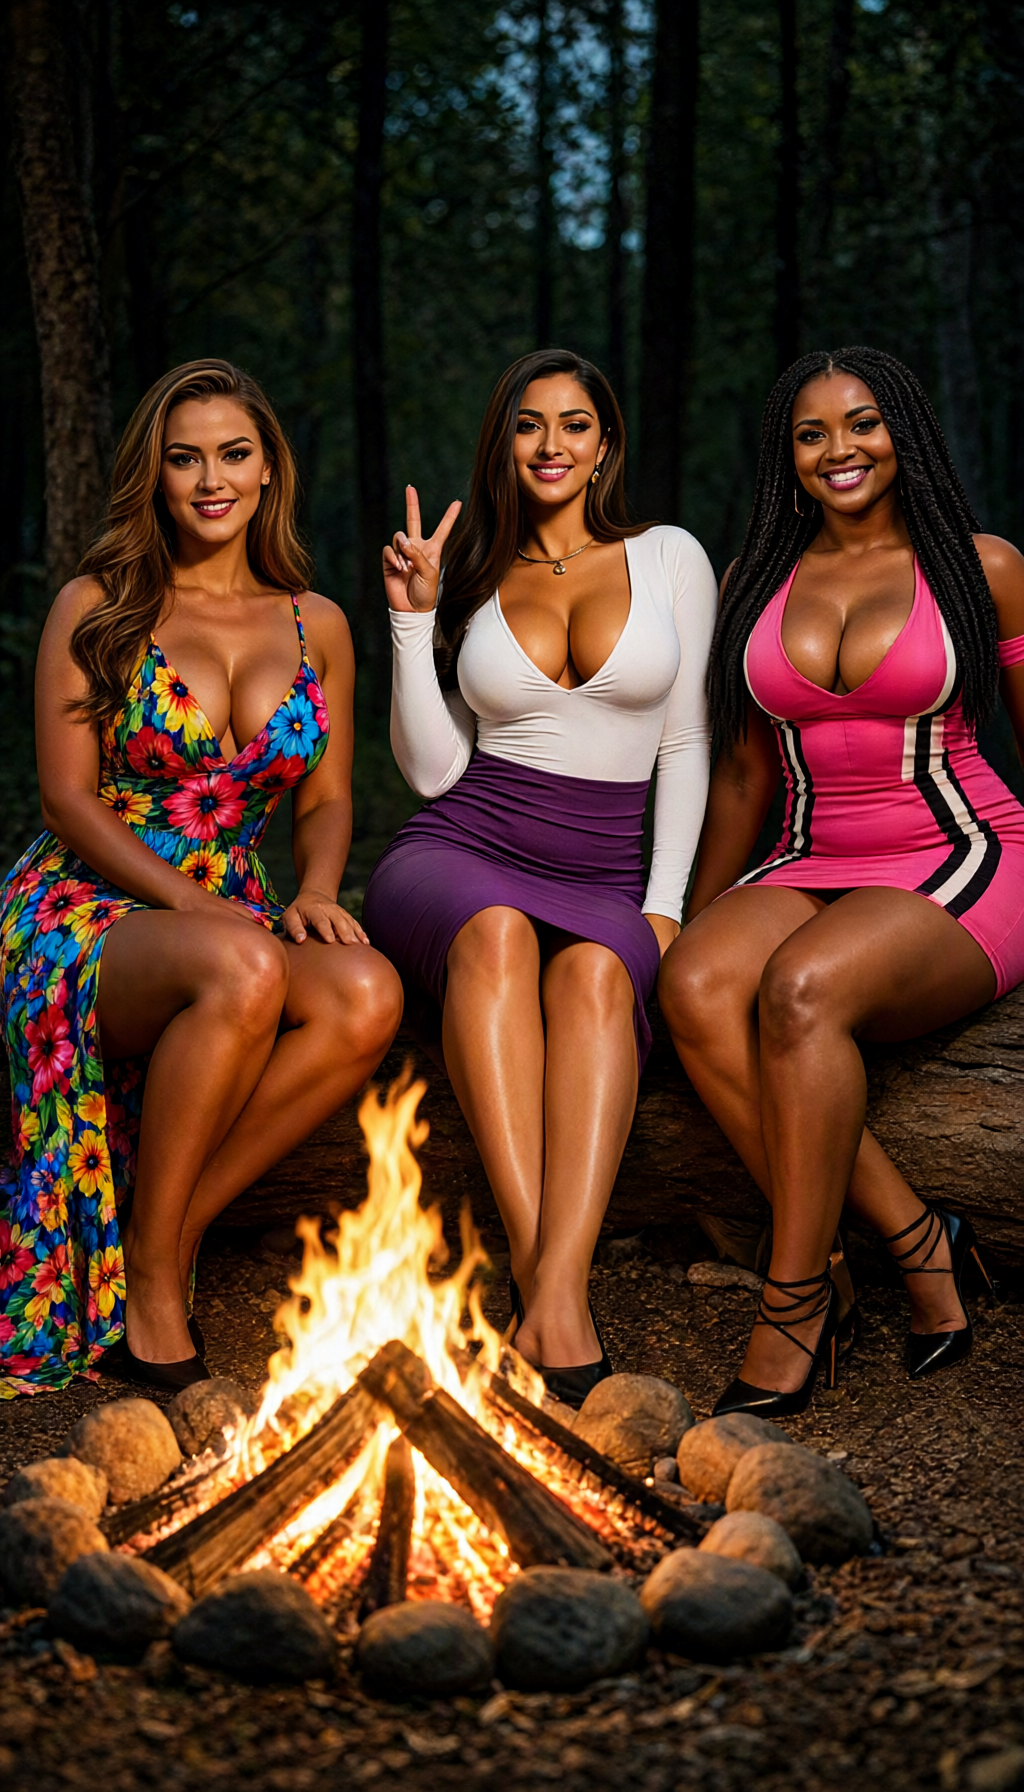

Task: Image Editing
Prompt: These three characters are sitting around a campfire in a forest
Negative prompt: 
Seed: 42
Qwen-Image Model Used: qwen-image-2.1-UC-Q4_K_M.gguf
Text Encoder: qwen3vl_8b_int8_convrot.safetensors
First reference image size: 576x1024
Number of Input Images: 3
Output Image Size: 1024x1792
Steps: 6
CFG: 1
Sampler: euler
Scheduler: simple
Viggle turbo Lora Used?: True
Viggle turbo Lora Name: Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors
Speed Lora Used?: False
Speed Lora Name: p_qwen_image_2.1_8step_v0.1.safetensors
Other LoRAs Used? -> Lora 1: False | Lora 2: False
Other LoRAs Used -> Lora 1: None | Lora 2: None
Cache Enabled: True
Cache dtype: default
✅ Completed in 13 min 21.80 sec


In [ ]:
# @title 2. 💥 Generate / Edit Image {"single-column":true}

import time
start_time = time.time()

positive_prompt = "These three characters are sitting around a campfire in a forest" # @param {"type":"string"}
negative_prompt = "" # @param {"type":"string"}
# @markdown ---
# @markdown ### Image Settings
generate_image = False # @param {type:"boolean"}
use_input_dimensions = False # @param {type:"boolean"}
aspect_ratio = "16:9 1K (1344x768)" # @param ["1:1 2K (2048x2048)", "4:3 2K (2400x1792)", "3:4 2K (1792x2400)", "3:2 2K (2528x1696)", "2:3 2K (1696x2528)", "16:9 2K (2752x1536)", "9:16 2K (1536x2752)", "1:1 1K (1024x1024)", "4:3 1K (1152x896)", "3:4 1K (896x1152)", "3:2 1K (1216x832)", "2:3 1K (832x1216)", "16:9 1K (1344x768)", "9:16 1K (768x1344)"]

aspect_ratios_map = {
    # 2K Resolutions natively supported by Qwen 2.1
    "1:1 2K (2048x2048)":  (2048, 2048),
    "4:3 2K (2400x1792)":  (2400, 1792),
    "3:4 2K (1792x2400)":  (1792, 2400),
    "3:2 2K (2528x1696)":  (2528, 1696),
    "2:3 2K (1696x2528)":  (1696, 2528),
    "16:9 2K (2752x1536)": (2752, 1536),
    "9:16 2K (1536x2752)": (1536, 2752),

    # Standard 1K Resolutions
    "1:1 1K (1024x1024)":  (1024, 1024),
    "4:3 1K (1152x896)":   (1152, 896),
    "3:4 1K (896x1152)":   (896, 1152),
    "3:2 1K (1216x832)":   (1216, 832),
    "2:3 1K (832x1216)":   (832, 1216),
    "16:9 1K (1344x768)":  (1344, 768),
    "9:16 1K (768x1344)":  (768, 1344),
}

new_width, new_height = aspect_ratios_map[aspect_ratio]
# @markdown ---
# @markdown ### Sampler Settings
seed = 42 # @param {"type":"integer"}
steps = 40 # @param {"type":"slider","min":1,"max":100,"step":1}
cfg = 1 # @param {"type":"slider","min":0,"max":10,"step":0.1}
sampler_name = "euler" # @param ["euler", "euler_cfg_pp", "euler_ancestral", "euler_ancestral_cfg_pp", "heun", "heunpp2", "exp_heun_2_x0", "exp_heun_2_x0_sde", "dpm_2", "dpm_2_ancestral","lms", "dpm_fast", "dpm_adaptive", "dpmpp_2s_ancestral", "dpmpp_2s_ancestral_cfg_pp", "dpmpp_sde", "dpmpp_sde_gpu","dpmpp_2m", "dpmpp_2m_cfg_pp", "dpmpp_2m_sde", "dpmpp_2m_sde_gpu", "dpmpp_2m_sde_heun", "dpmpp_2m_sde_heun_gpu", "dpmpp_3m_sde", "dpmpp_3m_sde_gpu", "ddpm", "lcm","ipndm", "ipndm_v", "deis", "cfgpp_ud10_ab", "res_multistep", "res_multistep_cfg_pp", "res_multistep_ancestral", "res_multistep_ancestral_cfg_pp","gradient_estimation", "gradient_estimation_cfg_pp", "er_sde", "seeds_2", "seeds_3", "sa_solver", "sa_solver_pece"]

scheduler = "simple" # @param ["simple","normal","karras","exponential","sgm_uniform","ddim_uniform","beta","linear_quadratic","kl_optimal"]
use_qwen_image_2_1_cache=True # @param {type:"boolean"}
cache_dtype = "default" # @param ["default", "int8", "int4"]
# @markdown ---
# @markdown ### LoRA Settings
use_viggle_turbo_lora=True # @param {type:"boolean"}
use_speedup_lora=False # @param {type:"boolean"}
use_lora_1=False # @param {type:"boolean"}
LoRA_1_Strength=1 # @param {"type":"slider","min":-1,"max":1,"step":0.01}
use_lora_2=False # @param {type:"boolean"}
LoRA_2_Strength=1 # @param {"type":"slider","min":-1,"max":1,"step":0.01}


display_generation_info = True # @param {type:"boolean"}

import random
seed = seed if seed != 0 else random.randint(0, 2**32 - 1)

file_uploaded_main = globals().get("file_uploaded_main", None)
reference_files = globals().get("reference_files", [])
ref_width = globals().get("ref_width", 0)
ref_height = globals().get("ref_height", 0)
number_of_references = globals().get("number_of_references", 0)
task = "Image Editing"
if generate_image or number_of_references == 0:
    task = "Text to Image Generation"
if use_viggle_turbo_lora:
    steps = 6

edit_input(
    image_path=file_uploaded_main,
    reference_paths=reference_files,
    positive_prompt=positive_prompt,
    negative_prompt=negative_prompt,
    generate_image=generate_image,
    use_input_dimensions=use_input_dimensions,
    width=int(new_width),
    height=int(new_height),
    seed=seed,
    steps=steps,
    cfg=cfg,
    sampler_name=sampler_name,
    scheduler=scheduler,
    use_viggle_turbo_lora=use_viggle_turbo_lora,
    use_turbo_lora=use_speedup_lora,
    use_lora_1=use_lora_1,
    LoRA_1_Strength=LoRA_1_Strength,
    use_lora_2=use_lora_2,
    LoRA_2_Strength=LoRA_2_Strength,
    use_qwen_image_2_1_cache=use_qwen_image_2_1_cache,
    cache_dtype=cache_dtype
)

end_time = time.time()
duration = end_time - start_time
mins, secs = divmod(duration, 60)

if display_generation_info:
    print("="*40)

    print(f"Task: {task}")
    print(f"Prompt: {positive_prompt}")
    print(f"Negative prompt: {negative_prompt}")
    print(f"Seed: {seed}")
    print(f"Qwen-Image Model Used: {unet_model}")
    print(f"Text Encoder: {text_encoder_model}")
    print(f"First reference image size: {ref_width}x{ref_height}")
    print(f"Number of Input Images: {number_of_references}")
    print(f"Output Image Size: {out_W}x{out_H}")
    print(f"Steps: {steps}")
    print(f"CFG: {cfg}")
    print(f"Sampler: {sampler_name}")
    print(f"Scheduler: {scheduler}")
    print(f"Viggle turbo Lora Used?: {use_viggle_turbo_lora}")
    print(f"Viggle turbo Lora Name: {viggle_turbo_lora}")
    print(f"Speed Lora Used?: {use_speedup_lora}")
    print(f"Speed Lora Name: {speedup_lora}")
    print(f"Other LoRAs Used? -> Lora 1: {use_lora_1} | Lora 2: {use_lora_2}")
    print(f"Other LoRAs Used -> Lora 1: {lora_1} | Lora 2: {lora_2}")
    print(f"Cache Enabled: {use_qwen_image_2_1_cache}")
    print(f"Cache dtype: {cache_dtype}")
    print(f"✅ Completed in {int(mins)} min {secs:.2f} sec")

    print("="*40)

gc.collect()
torch.cuda.empty_cache()
